In [2]:
!pip install nemo-curator

  Using cached nemo_curator-1.1.0-py3-none-any.whl.metadata (13 kB)
Using cached nemo_curator-1.1.0-py3-none-any.whl (464 kB)


In [1]:
from google.colab import files
uploaded = files.upload()

Saving dialogues_text.txt to dialogues_text (1).txt


In [10]:
import json

texts = []

with open("dialogues_text.txt") as f:
    for line in f:
        parts = line.strip().split("__eou__")
        for p in parts:
            p = p.strip()
            if p:
                texts.append(p)

print("Total samples:", len(texts))

with open("raw_data.jsonl", "w") as f:
    for t in texts:   # ALL DATA
        json.dump({"text": t}, f)
        f.write("\n")

print("Saved raw_data.jsonl")

Total samples: 102980
Saved raw_data.jsonl


In [11]:
import json
import re

cleaned = []
seen = set()

def clean_text(text):
    text = text.lower().strip()
    text = text.replace("\u2019", "'")  # fix unicode quotes
    text = re.sub(r"\s+", " ", text)    # remove extra spaces
    text = re.sub(r"\s+([.,!?])", r"\1", text)  # fix spacing before punctuation
    return text

def is_valid(text):
    if len(text) < 5:
        return False
    if text.isnumeric():
        return False
    return True

with open("raw_data.jsonl") as f:
    for line in f:
        obj = json.loads(line)
        text = clean_text(obj["text"])

        if not is_valid(text):
            continue

        if text in seen:
            continue

        seen.add(text)
        cleaned.append(text)

with open("cleaned_data.jsonl", "w") as f:
    for t in cleaned:
        json.dump({"text": t}, f)
        f.write("\n")

print("Pipeline complete")

Pipeline complete


In [12]:
def count_lines(file):
    return sum(1 for _ in open(file))

print("Before:", count_lines("raw_data.jsonl"))
print("After:", count_lines("cleaned_data.jsonl"))

Before: 102980
After: 81779


In [13]:
with open("cleaned_data.jsonl") as f:
    for i, line in enumerate(f):
        if i > 10:
            break
        print(line)

{"text": "the kitchen stinks."}

{"text": "i'll throw out the garbage."}

{"text": "so dick, how about getting some coffee for tonight?"}

{"text": "coffee? i don ' t honestly like that kind of stuff."}

{"text": "come on, you can at least try a little, besides your cigarette."}

{"text": "what ' s wrong with that? cigarette is the thing i go crazy for."}

{"text": "not for me, dick."}

{"text": "are things still going badly with your houseguest?"}

{"text": "getting worse. now he ' s eating me out of house and home. i ' ve tried talking to him but it all goes in one ear and out the other. he makes himself at home, which is fine. but what really gets me is that yesterday he walked into the living room in the raw and i had company over! that was the last straw."}

{"text": "leo, i really think you ' re beating around the bush with this guy. i know he used to be your best friend in college, but i really think it ' s time to lay down the law."}

{"text": "you ' re right. everything is pro

Before: 102980
After: 81779


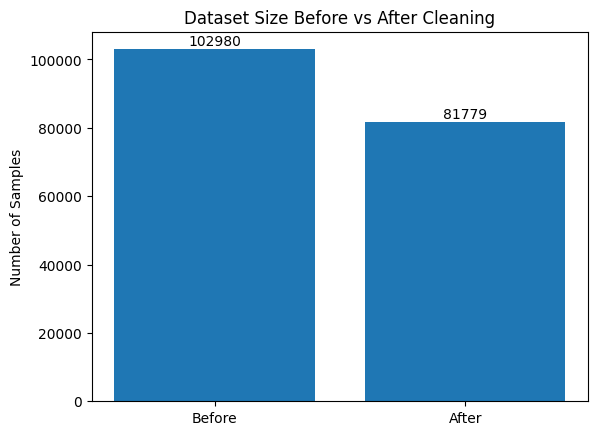

In [15]:
import matplotlib.pyplot as plt

def count_lines(file):
    return sum(1 for _ in open(file))

# Get values dynamically
before = count_lines("raw_data.jsonl")
after = count_lines("cleaned_data.jsonl")

print("Before:", before)
print("After:", after)

# Plot
labels = ["Before", "After"]
values = [before, after]

plt.bar(labels, values)
plt.title("Dataset Size Before vs After Cleaning")
plt.ylabel("Number of Samples")

for i, v in enumerate(values):
    plt.text(i, v + (0.01 * max(values)), str(v), ha='center')

plt.show()

Avg length BEFORE: 13.61050689454263
Avg length AFTER: 12.171657760549774


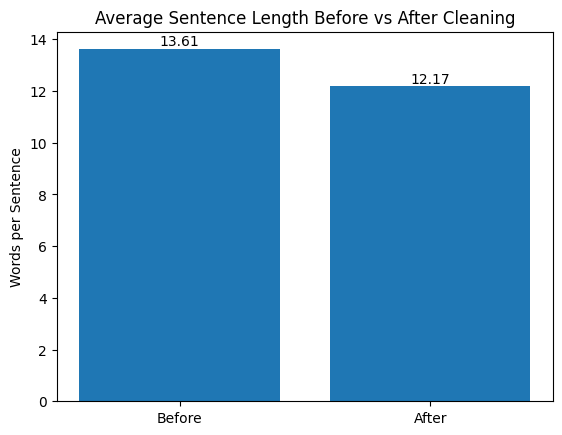

In [16]:
import json
import matplotlib.pyplot as plt

def avg_length(file):
    total = 0
    count = 0
    with open(file) as f:
        for line in f:
            text = json.loads(line)["text"]
            total += len(text.split())
            count += 1
    return total / count

# Compute values
before_avg = avg_length("raw_data.jsonl")
after_avg = avg_length("cleaned_data.jsonl")

print("Avg length BEFORE:", before_avg)
print("Avg length AFTER:", after_avg)

# Plot
labels = ["Before", "After"]
values = [before_avg, after_avg]

plt.bar(labels, values)
plt.title("Average Sentence Length Before vs After Cleaning")
plt.ylabel("Words per Sentence")

for i, v in enumerate(values):
    plt.text(i, v + (0.01 * max(values)), f"{v:.2f}", ha='center')

plt.show()